In [1]:
"""Benchmark training/inference speeds for mirror-mouse-separate dataset.
Run this in a Jupyter notebook on a GPU machine.
"""

import time
import torch
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from omegaconf import DictConfig, OmegaConf
from lightning_pose.utils.scripts import (
    get_data_module,
    get_model,
    get_dataset,
    get_imgaug_transform,
    get_loss_factories,
)
from lightning_pose.api.model import Model


In [10]:
import torch
import gc

# Force garbage collection on CPU
gc.collect()

CUDA_DEVICE = 3  # only clean this GPU

if torch.cuda.is_available() and CUDA_DEVICE < torch.cuda.device_count():
    # Set current device to 3
    torch.cuda.set_device(CUDA_DEVICE)

    # Clear CUDA cache ONLY on current device (3)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    # Check memory for that device
    print(f"GPU {CUDA_DEVICE}: {torch.cuda.memory_allocated(CUDA_DEVICE) / 1e9:.2f} GB allocated")
else:
    print("CUDA not available or device index out of range")

GPU 3: 0.01 GB allocated


In [ ]:
# import torch
# import gc

# # Force garbage collection
# gc.collect()

# # clear CUDA ca

# # Clear CUDA cache
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
#     torch.cuda.synchronize()
    
#     # Check memory
#     for i in range(torch.cuda.device_count()):
#         print(f"GPU {i}: {torch.cuda.memory_allocated(i) / 1e9:.2f} GB allocated")

In [9]:
# Cell 0: Set CUDA device
import torch
import os

# Option 1: Set via environment variable (before importing torch)
# os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# Option 2: Set device explicitly (after importing torch)
CUDA_DEVICE = 3  # Change this to your desired GPU number

if torch.cuda.is_available():
    if CUDA_DEVICE >= torch.cuda.device_count():
        print(f"⚠️  WARNING: Device {CUDA_DEVICE} not available. Available devices: 0-{torch.cuda.device_count()-1}")
        CUDA_DEVICE = 0
    torch.cuda.set_device(CUDA_DEVICE)
    print(f"✅ Set to use CUDA device {CUDA_DEVICE}: {torch.cuda.get_device_name(CUDA_DEVICE)}")
    print(f"   Total memory: {torch.cuda.get_device_properties(CUDA_DEVICE).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No CUDA devices available")

✅ Set to use CUDA device 3: NVIDIA L4
   Total memory: 23.8 GB


In [3]:
"""Run benchmarks for all scenarios with separate folders for each batch size."""

import time
import torch
import lightning.pytorch as pl
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from omegaconf import DictConfig, OmegaConf
from lightning_pose.utils.scripts import (
    get_data_module,
    get_model,
    get_dataset,
    get_imgaug_transform,
    get_loss_factories,
)
from lightning_pose.api.model import Model


def move_batch_to_device(batch: dict, device: torch.device) -> dict:
    """Move batch dictionary to specified device."""
    batch_device = {}
    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            batch_device[key] = value.to(device)
        elif isinstance(value, (list, tuple)):
            batch_device[key] = [
                v.to(device) if isinstance(v, torch.Tensor) else v
                for v in value
            ]
        else:
            batch_device[key] = value
    return batch_device


def extract_config_metadata(cfg: DictConfig):
    """Extract metadata from config file."""
    metadata = {
        "architecture": cfg.model.backbone,
        "batch_size": cfg.training.train_batch_size,
        "model_type": cfg.model.model_type,
    }
    
    return metadata


def configure_scenario(cfg: DictConfig, backbone: str, use_3d_loss: bool, use_patch_masking: bool):
    """Configure a single scenario by modifying the config."""
    # Set backbone
    cfg.model.backbone = backbone
    
    # Configure patch masking
    if use_patch_masking:
        cfg.training.patch_mask.init_ratio = 0.1
        cfg.training.patch_mask.final_ratio = 0.1
    else:
        cfg.training.patch_mask.init_ratio = 0.0
        cfg.training.patch_mask.final_ratio = 0.0
    
    # Configure 3D loss (supervised_pairwise_projections)
    if use_3d_loss:
        if "supervised_pairwise_projections" not in cfg.losses:
            cfg.losses.supervised_pairwise_projections = OmegaConf.create({
                "log_weight": 0.3,
                "epsilon": None
            })
    else:
        if "supervised_pairwise_projections" in cfg.losses:
            del cfg.losses.supervised_pairwise_projections
    
    return cfg


def generate_results_dir_name(backbone: str, use_3d_loss: bool, use_patch_masking: bool, mode: str, batch_size: int):
    """Generate a descriptive results directory name."""
    arch = "vits" if backbone == "vits_dino" else "vitb"
    loss = "3dloss" if use_3d_loss else "no_loss"
    patch = "patch" if use_patch_masking else "no_patch"
    return f"{arch}_{loss}_{patch}_{mode}_batch{batch_size}"


def benchmark_single_config(
    cfg: DictConfig,
    batch_size: int,
    mode: str,  # "train" or "inference"
    num_batches: int,
    warmup_batches: int,
    device: torch.device,
    output_dir: Path,
):
    """Run a single benchmark for a specific batch size and mode."""
    
    # Set batch size in config
    cfg.training.train_batch_size = batch_size
    cfg.training.val_batch_size = batch_size
    cfg.training.test_batch_size = batch_size
    
    # Extract metadata
    metadata = extract_config_metadata(cfg)
    metadata["batch_size"] = batch_size
    
    print(f"\n  Running {mode} with batch_size={batch_size}...")
    
    # Get dataset and imgaug transform
    imgaug_transform = get_imgaug_transform(cfg)
    dataset = get_dataset(cfg, cfg.data.data_dir, imgaug_transform)
    
    # Create data module
    data_module = get_data_module(cfg, dataset)
    data_module.setup("fit")
    train_loader = data_module.train_dataloader()
    
    # Create model
    loss_factories = get_loss_factories(cfg, data_module)
    model = get_model(cfg, data_module, loss_factories)
    model = model.to(device)
    
    all_results = []
    
    # Warmup phase
    print(f"    Warming up ({warmup_batches} batches)...")
    for i, batch in enumerate(train_loader):
        if i >= warmup_batches:
            break
        batch_device = move_batch_to_device(batch, device)
        with torch.no_grad():
            _ = model.training_step(batch_device, 0)
    
    if mode == "inference":
        print(f"    Benchmarking inference ({num_batches} batches)...")
        model.eval()
        batch_iter = iter(train_loader)
        
        for batch_idx in range(num_batches):
            try:
                batch = next(batch_iter)
            except StopIteration:
                batch_iter = iter(train_loader)
                batch = next(batch_iter)
            
            batch_device = move_batch_to_device(batch, device)
            
            if device.type == "cuda":
                torch.cuda.synchronize()
            
            start_time = time.perf_counter()
            
            with torch.no_grad():
                _ = model.training_step(batch_device, 0)
            
            if device.type == "cuda":
                torch.cuda.synchronize()
            
            end_time = time.perf_counter()
            batch_time = end_time - start_time
            
            result = {
                "mode": "inference",
                "batch_idx": batch_idx,
                "batch_size": batch_size,
                "time_per_batch": batch_time,
                "time_per_batch_ms": batch_time * 1000,
                "frames_per_second": batch_size / batch_time,
                **{k: v for k, v in metadata.items() if k != "batch_size"}
            }
            all_results.append(result)
            
            if (batch_idx + 1) % 10 == 0:
                avg_fps = np.mean([r["frames_per_second"] for r in all_results[-10:]])
                print(f"      Batch {batch_idx+1}/{num_batches}: {avg_fps:.2f} frames/sec")
        
        avg_fps = np.mean([r["frames_per_second"] for r in all_results])
        print(f"    Inference average: {avg_fps:.2f} frames/sec")
    
    elif mode == "train":
        print(f"    Benchmarking training ({num_batches} batches)...")
        model.train()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        batch_iter = iter(train_loader)
        
        for batch_idx in range(num_batches):
            try:
                batch = next(batch_iter)
            except StopIteration:
                batch_iter = iter(train_loader)
                batch = next(batch_iter)
            
            batch_device = move_batch_to_device(batch, device)
            
            if device.type == "cuda":
                torch.cuda.synchronize()
            
            start_time = time.perf_counter()
            
            optimizer.zero_grad()
            loss = model.training_step(batch_device, 0)
            if isinstance(loss, dict):
                loss = loss.get("loss", list(loss.values())[0])
            loss.backward()
            optimizer.step()
            
            if device.type == "cuda":
                torch.cuda.synchronize()
            
            end_time = time.perf_counter()
            batch_time = end_time - start_time
            
            result = {
                "mode": "training",
                "batch_idx": batch_idx,
                "batch_size": batch_size,
                "time_per_batch": batch_time,
                "time_per_batch_ms": batch_time * 1000,
                "iterations_per_second": 1.0 / batch_time,
                **{k: v for k, v in metadata.items() if k != "batch_size"}
            }
            all_results.append(result)
            
            if (batch_idx + 1) % 10 == 0:
                avg_ips = np.mean([r["iterations_per_second"] for r in all_results[-10:]])
                print(f"      Batch {batch_idx+1}/{num_batches}: {avg_ips:.2f} iter/sec")
        
        avg_ips = np.mean([r["iterations_per_second"] for r in all_results])
        print(f"    Training average: {avg_ips:.2f} iter/sec")
    
    # Convert to DataFrame and save
    results_df = pd.DataFrame(all_results)
    output_file = output_dir / "benchmark_results.csv"
    results_df.to_csv(output_file, index=False)
    
    # Save config
    config_copy_path = output_dir / "config.yaml"
    OmegaConf.save(cfg, config_copy_path)
    
    print(f"    ✅ Results saved to: {output_file}")
    
    return results_df


def benchmark_from_config(
    config_path: str = None,
    config: DictConfig = None,
    backbone: str = None,
    use_3d_loss: bool = None,
    use_patch_masking: bool = None,
    train_batch_sizes: list = None,
    inference_batch_sizes: list = None,
    num_batches: int = 100,
    warmup_batches: int = 50,
    cuda_device: int = 2,
    add_timestamp: bool = True,
):
    """Benchmark model with separate folders for each batch size and mode."""
    
    # Load config
    if config_path is not None:
        cfg = OmegaConf.load(config_path)
    elif config is not None:
        cfg = config
    else:
        raise ValueError("Must provide either config_path or config")
    
    # Configure scenario if parameters provided
    if backbone is not None and use_3d_loss is not None and use_patch_masking is not None:
        cfg = configure_scenario(cfg, backbone, use_3d_loss, use_patch_masking)
    
    # Default batch sizes
    if train_batch_sizes is None:
        train_batch_sizes = [8, 16, 32]
    if inference_batch_sizes is None:
        inference_batch_sizes = [8, 16, 32, 64]
    
    # Base output directory
    base_output_dir = Path("/teamspace/studios/this_studio/outputs_training_time")
    
    # Set device
    if torch.cuda.is_available():
        torch.cuda.set_device(cuda_device)
        device = torch.device(f"cuda:{cuda_device}")
        print(f"Using device: {device}")
        print(f"GPU: {torch.cuda.get_device_name(cuda_device)}")
    else:
        device = torch.device("cpu")
        print("⚠️  WARNING: No GPU detected!")
    
    # Extract base metadata
    metadata = extract_config_metadata(cfg)
    print(f"\nBase Configuration:")
    for key, value in metadata.items():
        print(f"  {key}: {value}")
    
    all_results = []
    
    # Run training benchmarks - separate folder for each batch size
    print(f"\n{'='*60}")
    print(f"TRAINING BENCHMARKS")
    print(f"{'='*60}")
    for batch_size in train_batch_sizes:
        try:
            # Generate folder name for this specific run
            results_dir = generate_results_dir_name(
                cfg.model.backbone, 
                use_3d_loss if use_3d_loss is not None else ("supervised_pairwise_projections" in cfg.losses),
                use_patch_masking if use_patch_masking is not None else (cfg.training.patch_mask.init_ratio > 0),
                "train",
                batch_size
            )
            
            if add_timestamp:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                results_dir = f"{results_dir}_{timestamp}"
            
            output_dir = base_output_dir / results_dir
            output_dir.mkdir(parents=True, exist_ok=True)
            print(f"\n  Folder: {results_dir}")
            
            # Create a fresh copy of config for this run
            cfg_copy = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
            
            results_df = benchmark_single_config(
                cfg=cfg_copy,
                batch_size=batch_size,
                mode="train",
                num_batches=num_batches,
                warmup_batches=warmup_batches,
                device=device,
                output_dir=output_dir,
            )
            all_results.append(results_df)
            
        except Exception as e:
            print(f"    ❌ Failed batch_size={batch_size}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Run inference benchmarks - separate folder for each batch size
    print(f"\n{'='*60}")
    print(f"INFERENCE BENCHMARKS")
    print(f"{'='*60}")
    for batch_size in inference_batch_sizes:
        try:
            # Generate folder name for this specific run
            results_dir = generate_results_dir_name(
                cfg.model.backbone,
                use_3d_loss if use_3d_loss is not None else ("supervised_pairwise_projections" in cfg.losses),
                use_patch_masking if use_patch_masking is not None else (cfg.training.patch_mask.init_ratio > 0),
                "inference",
                batch_size
            )
            
            if add_timestamp:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                results_dir = f"{results_dir}_{timestamp}"
            
            output_dir = base_output_dir / results_dir
            output_dir.mkdir(parents=True, exist_ok=True)
            print(f"\n  Folder: {results_dir}")
            
            # Create a fresh copy of config for this run
            cfg_copy = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
            
            results_df = benchmark_single_config(
                cfg=cfg_copy,
                batch_size=batch_size,
                mode="inference",
                num_batches=num_batches,
                warmup_batches=warmup_batches,
                device=device,
                output_dir=output_dir,
            )
            all_results.append(results_df)
            
        except Exception as e:
            print(f"    ❌ Failed batch_size={batch_size}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"\n{'='*60}")
    print(f"All benchmarks complete!")
    print(f"{'='*60}")
    
    return all_results



In [4]:
# Define all 8 scenarios
scenarios = [
    # ("vits_dino", False, False, "vit-s + no loss + no patch"),
    # ("vits_dino", True, False, "vit-s + 3d loss + no patch"),
    # ("vits_dino", False, True, "vit-s + no loss + patch"),
    # ("vits_dino", True, True, "vit-s + 3d loss + patch"),
    # ("vitb_dino", False, False, "vit-b + no loss + no patch"),
    ("vitb_dino", True, False, "vit-b + 3d loss + no patch"),
    # ("vitb_dino", False, True, "vit-b + no loss + patch"),
    # ("vitb_dino", True, True, "vit-b + 3d loss + patch"),
]

# Base config path
base_config_path = "/teamspace/studios/this_studio/lp3d-analysis/configs/config_chickadee_inference_time.yaml"

# Run benchmarks for each scenario
print(f"\n{'='*80}")
print(f"STARTING BENCHMARK RUN FOR {len(scenarios)} SCENARIOS")
print(f"Each scenario will create separate folders for each batch size and mode")
print(f"{'='*80}")

for idx, (backbone, use_3d_loss, use_patch_masking, description) in enumerate(scenarios, 1):
    print(f"\n{'='*80}")
    print(f"SCENARIO {idx}/8: {description}")
    print(f"  Backbone: {backbone}")
    print(f"  3D Loss: {use_3d_loss}")
    print(f"  Patch Masking: {use_patch_masking}")
    print(f"{'='*80}")
    
    try:
        # Load base config
        cfg = OmegaConf.load(base_config_path)
        cfg = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
        
        # Run benchmark - will create separate folders for each batch size
        results = benchmark_from_config(
            config=cfg,
            backbone=backbone,
            use_3d_loss=use_3d_loss,
            use_patch_masking=use_patch_masking,
            # train_batch_sizes=[8, 16, 32],
            # inference_batch_sizes=[8, 16, 32, 64],
            train_batch_sizes=[],
            inference_batch_sizes=[32],
            num_batches=100,
            warmup_batches=50,
            cuda_device=3,
            add_timestamp=False,
        )
        
        print(f"\n✅ Successfully completed scenario {idx}/8: {description}")
        
    except Exception as e:
        print(f"\n❌ Failed scenario {idx}/8: {description}")
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        print(f"\nContinuing to next scenario...\n")
        continue

print(f"\n{'='*80}")
print("ALL SCENARIOS COMPLETE!")
print(f"{'='*80}")


STARTING BENCHMARK RUN FOR 1 SCENARIOS
Each scenario will create separate folders for each batch size and mode

SCENARIO 1/8: vit-b + 3d loss + no patch
  Backbone: vitb_dino
  3D Loss: True
  Patch Masking: False
Using device: cuda:3
GPU: NVIDIA L4

Base Configuration:
  architecture: vitb_dino
  batch_size: 8
  model_type: heatmap_multiview_transformer

TRAINING BENCHMARKS

INFERENCE BENCHMARKS

  Folder: vitb_3dloss_no_patch_inference_batch32

  Running inference with batch_size=32...
Using MultiviewHeatmapDataset


KeyboardInterrupt: 

SV Vits_dino benchmark

In [5]:
def benchmark_from_config(
    config_path: str = None,
    config: DictConfig = None,
    backbone: str = None,
    use_3d_loss: bool = None,
    use_patch_masking: bool = None,
    train_batch_sizes: list = None,
    inference_batch_sizes: list = None,
    num_batches: int = 100,
    warmup_batches: int = 50,
    cuda_device: int = 3,
    add_timestamp: bool = False,
):
    """Benchmark model with separate folders for each batch size and mode."""
    
    # Load config
    if config_path is not None:
        cfg = OmegaConf.load(config_path)
    elif config is not None:
        cfg = config
    else:
        raise ValueError("Must provide either config_path or config")
    
    # Configure scenario if parameters provided
    if backbone is not None and use_3d_loss is not None and use_patch_masking is not None:
        cfg = configure_scenario(cfg, backbone, use_3d_loss, use_patch_masking)
    
    # Detect if this is a single-view transformer (heatmap model with multiple views)
    is_single_view = (
        cfg.model.model_type == "heatmap" and 
        cfg.data.get("view_names") is not None and 
        len(cfg.data.view_names) > 1
    )
    
    # Default batch sizes
    if train_batch_sizes is None:
        train_batch_sizes = [8, 16, 32]
    if inference_batch_sizes is None:
        inference_batch_sizes = [8, 16, 32, 64]
    
    # Base output directory
    base_output_dir = Path("/teamspace/studios/this_studio/outputs_training_time")
    
    # Set device
    if torch.cuda.is_available():
        torch.cuda.set_device(cuda_device)
        device = torch.device(f"cuda:{cuda_device}")
        print(f"Using device: {device}")
        print(f"GPU: {torch.cuda.get_device_name(cuda_device)}")
    else:
        device = torch.device("cpu")
        print("⚠️  WARNING: No GPU detected!")
    
    # Extract base metadata
    metadata = extract_config_metadata(cfg)
    print(f"\nBase Configuration:")
    for key, value in metadata.items():
        print(f"  {key}: {value}")
    if is_single_view:
        print(f"  Model: Single-view transformer (processing {len(cfg.data.view_names)} views independently)")
    
    all_results = []
    
    # Run training benchmarks - separate folder for each batch size
    print(f"\n{'='*60}")
    print(f"TRAINING BENCHMARKS")
    print(f"{'='*60}")
    for batch_size in train_batch_sizes:
        try:
            # Generate folder name for this specific run
            results_dir = generate_results_dir_name(
                cfg.model.backbone, 
                use_3d_loss if use_3d_loss is not None else ("supervised_pairwise_projections" in cfg.losses),
                use_patch_masking if use_patch_masking is not None else (cfg.training.patch_mask.init_ratio > 0),
                "train",
                batch_size,
                is_single_view=is_single_view  # Pass the flag
            )
            
            if add_timestamp:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                results_dir = f"{results_dir}_{timestamp}"
            
            output_dir = base_output_dir / results_dir
            output_dir.mkdir(parents=True, exist_ok=True)
            print(f"\n  Folder: {results_dir}")
            
            # Create a fresh copy of config for this run
            cfg_copy = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
            
            results_df = benchmark_single_config(
                cfg=cfg_copy,
                batch_size=batch_size,
                mode="train",
                num_batches=num_batches,
                warmup_batches=warmup_batches,
                device=device,
                output_dir=output_dir,
            )
            all_results.append(results_df)
            
        except Exception as e:
            print(f"    ❌ Failed batch_size={batch_size}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Run inference benchmarks - separate folder for each batch size
    print(f"\n{'='*60}")
    print(f"INFERENCE BENCHMARKS")
    print(f"{'='*60}")
    for batch_size in inference_batch_sizes:
        try:
            # Generate folder name for this specific run
            results_dir = generate_results_dir_name(
                cfg.model.backbone,
                use_3d_loss if use_3d_loss is not None else ("supervised_pairwise_projections" in cfg.losses),
                use_patch_masking if use_patch_masking is not None else (cfg.training.patch_mask.init_ratio > 0),
                "inference",
                batch_size,
                is_single_view=is_single_view  # Pass the flag
            )
            
            if add_timestamp:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                results_dir = f"{results_dir}_{timestamp}"
            
            output_dir = base_output_dir / results_dir
            output_dir.mkdir(parents=True, exist_ok=True)
            print(f"\n  Folder: {results_dir}")
            
            # Create a fresh copy of config for this run
            cfg_copy = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
            
            results_df = benchmark_single_config(
                cfg=cfg_copy,
                batch_size=batch_size,
                mode="inference",
                num_batches=num_batches,
                warmup_batches=warmup_batches,
                device=device,
                output_dir=output_dir,
            )
            all_results.append(results_df)
            
        except Exception as e:
            print(f"    ❌ Failed batch_size={batch_size}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"\n{'='*60}")
    print(f"All benchmarks complete!")
    print(f"{'='*60}")
    
    return all_results

def generate_results_dir_name(backbone: str, use_3d_loss: bool, use_patch_masking: bool, mode: str, batch_size: int, is_single_view: bool = False):
    """Generate a descriptive results directory name."""
    if is_single_view:
        # Single-view naming: SV_vits or SV_vitb
        arch = "SV_vits" if backbone == "vits_dino" else "SV_vitb"
    else:
        # Multiview naming: vits or vitb
        arch = "vits" if backbone == "vits_dino" else "vitb"
    
    loss = "3dloss" if use_3d_loss else "no_loss"
    patch = "patch" if use_patch_masking else "no_patch"
    return f"{arch}_{loss}_{patch}_{mode}_batch{batch_size}"


# Single-view transformer benchmarks for vits and vitb

base_config_path = "/teamspace/studios/this_studio/lp3d-analysis/configs/config_chickadee_inference_time.yaml"

# Single-view scenarios to test
single_view_scenarios = [
    # ("vits_dino", False, "SV_vits no patch"),
    ("vitb_dino", False, "SV_vitb no patch"),
]

print(f"\n{'='*80}")
print(f"STARTING SINGLE-VIEW TRANSFORMER BENCHMARKS")
print(f"{'='*80}")

for backbone, use_patch_masking, description in single_view_scenarios:
    print(f"\n{'='*80}")
    print(f"SCENARIO: {description}")
    print(f"  Backbone: {backbone}")
    print(f"  Patch Masking: {use_patch_masking}")
    print(f"{'='*80}")
    
    try:
        # Load base config
        cfg = OmegaConf.load(base_config_path)
        cfg = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
        
        # Configure for single-view transformer (but keep all views)
        cfg.model.model_type = "heatmap"  # Single-view model
        cfg.model.backbone = backbone
        cfg.data.camera_params_file = None
        
        # Configure patch masking
        if use_patch_masking:
            cfg.training.patch_mask.init_ratio = 0.1
            cfg.training.patch_mask.final_ratio = 0.25
        else:
            cfg.training.patch_mask.init_ratio = 0.0
            cfg.training.patch_mask.final_ratio = 0.0
        
        # Remove 3D loss
        if "supervised_pairwise_projections" in cfg.losses:
            del cfg.losses.supervised_pairwise_projections
        
        # Run benchmark
        results = benchmark_from_config(
            config=cfg,
            backbone=backbone,
            use_3d_loss=False,  # Not applicable for single-view
            use_patch_masking=use_patch_masking,
            train_batch_sizes=[],
            inference_batch_sizes=[64],
            num_batches=100,
            warmup_batches=50,
            cuda_device=CUDA_DEVICE,
            add_timestamp=False,
        )
        
        print(f"✅ Completed: {description}")
        
    except Exception as e:
        print(f"❌ Failed: {description}")
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print("ALL SINGLE-VIEW SCENARIOS COMPLETE!")
print(f"{'='*80}")


STARTING SINGLE-VIEW TRANSFORMER BENCHMARKS

SCENARIO: SV_vitb no patch
  Backbone: vitb_dino
  Patch Masking: False
Using device: cuda:3
GPU: NVIDIA L4

Base Configuration:
  architecture: vitb_dino
  batch_size: 8
  model_type: heatmap
  Model: Single-view transformer (processing 6 views independently)

TRAINING BENCHMARKS

INFERENCE BENCHMARKS

  Folder: SV_vitb_no_loss_no_patch_inference_batch64

  Running inference with batch_size=64...
Using MultiviewHeatmapDataset
Number of labeled images in the full dataset (train+val+test): 377
val: updating children datasets with resize imgaug pipeline
test: updating children datasets with resize imgaug pipeline
Dataset splits -- train: 359, val: 18, test: 0

Initializing a HeatmapTracker instance with vitb_dino backbone.
    Warming up (50 batches)...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/lightning/pytorch/core/module.py:445: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


    Benchmarking inference (100 batches)...
      Batch 10/100: 24.12 frames/sec
      Batch 20/100: 25.43 frames/sec
      Batch 30/100: 25.37 frames/sec
      Batch 40/100: 23.96 frames/sec
      Batch 50/100: 25.40 frames/sec
      Batch 60/100: 25.36 frames/sec
      Batch 70/100: 23.91 frames/sec
      Batch 80/100: 25.40 frames/sec
      Batch 90/100: 25.40 frames/sec
      Batch 100/100: 24.03 frames/sec
    Inference average: 24.84 frames/sec
    ✅ Results saved to: /teamspace/studios/this_studio/outputs_training_time/SV_vitb_no_loss_no_patch_inference_batch64/benchmark_results.csv

All benchmarks complete!
✅ Completed: SV_vitb no patch

ALL SINGLE-VIEW SCENARIOS COMPLETE!


with single view 

Loading all benchmark results...
Found 60 result files

Loaded 6000 total batch records
Architectures found: ['SV_vitb' 'SV_vits' 'vitb' 'vits']

Creating publication-quality plots...
Including models: ['SV_vitb', 'SV_vits', 'vitb', 'vits']

1. Creating training time comparison plot...


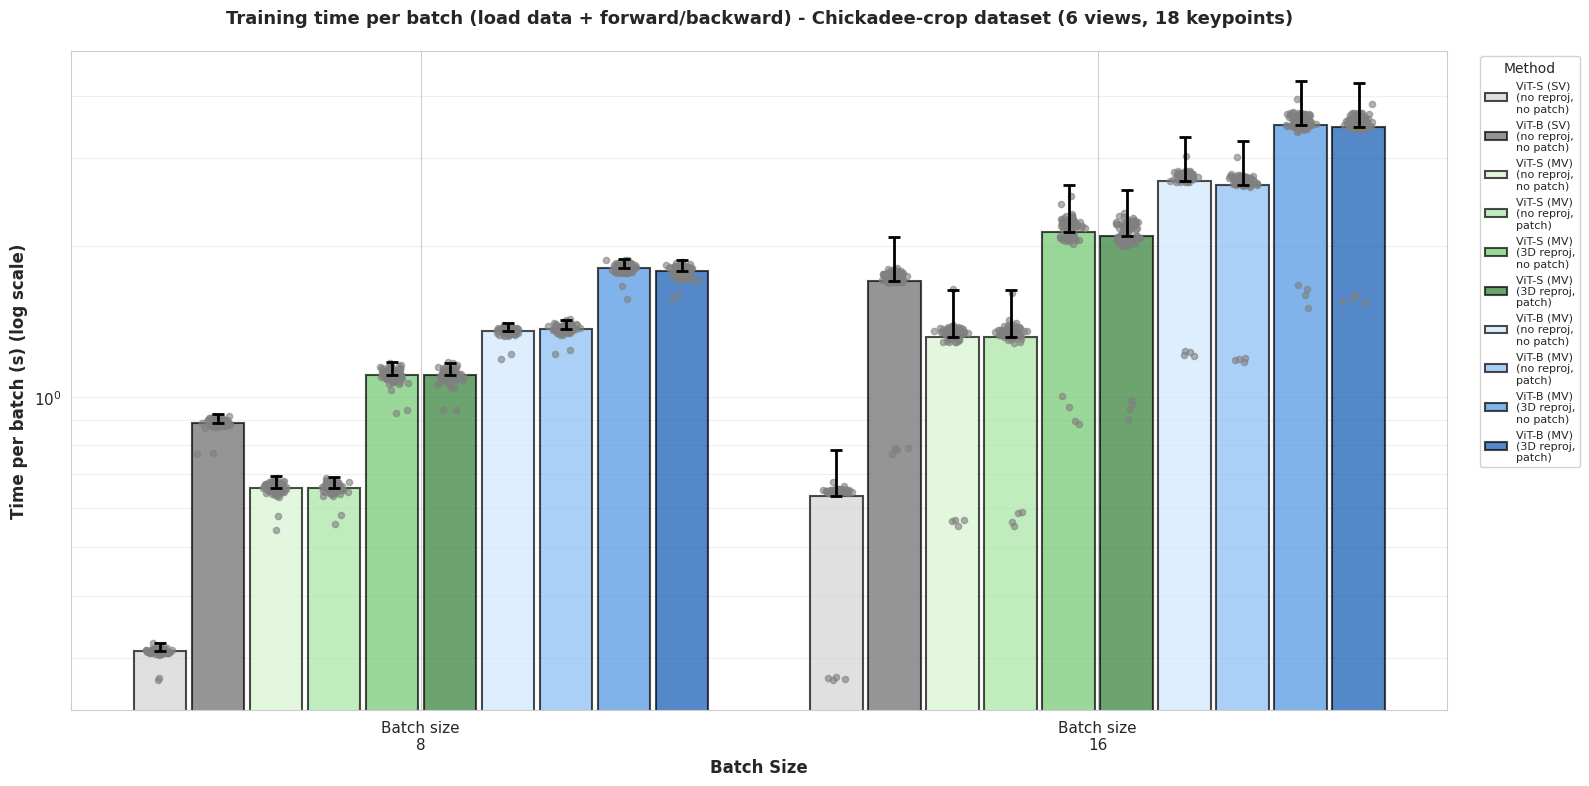


2. Creating inference time comparison plot...


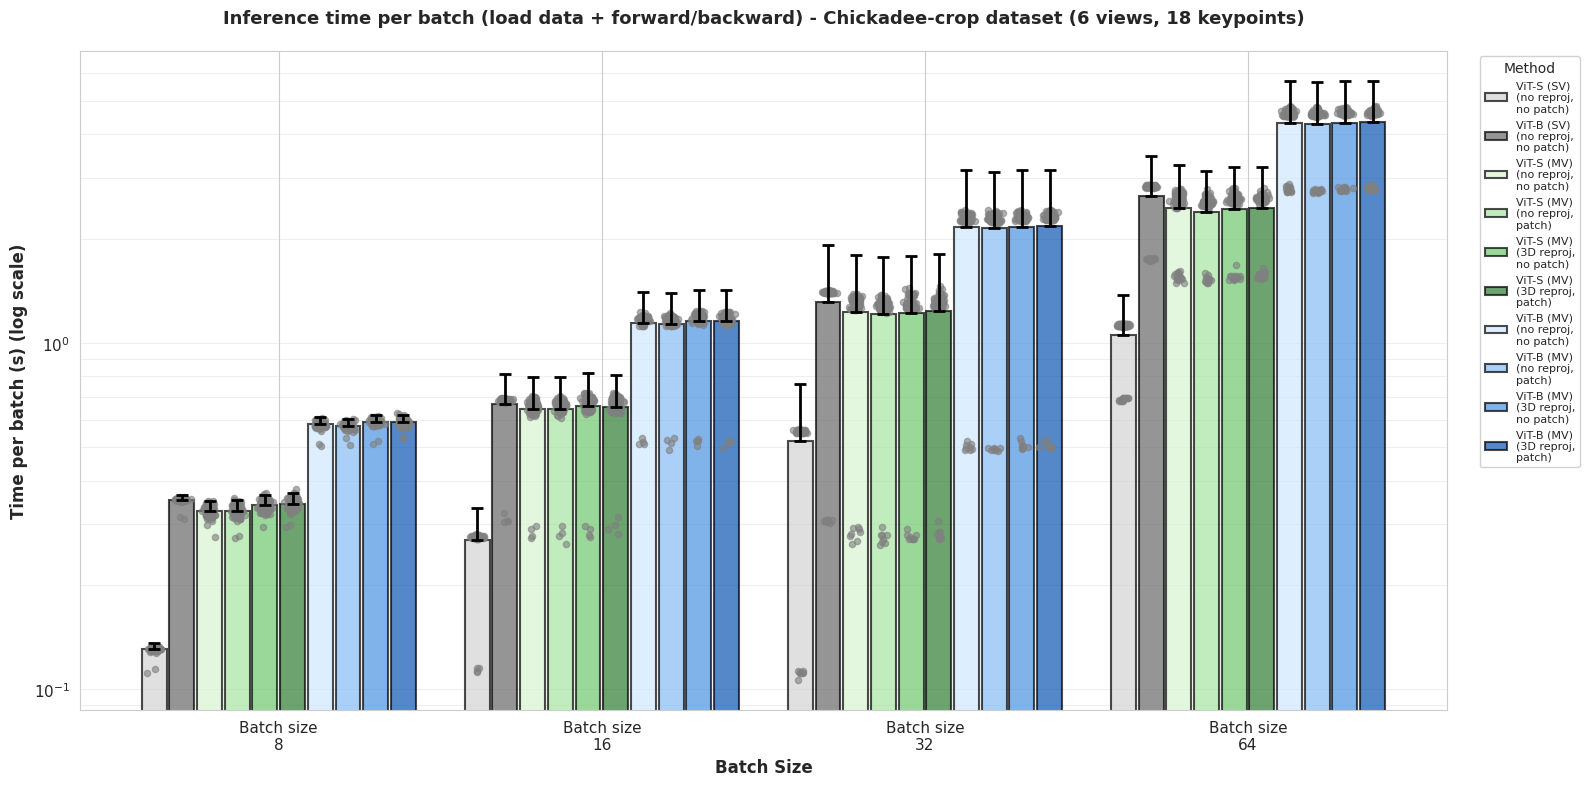


3. Creating training throughput plot...


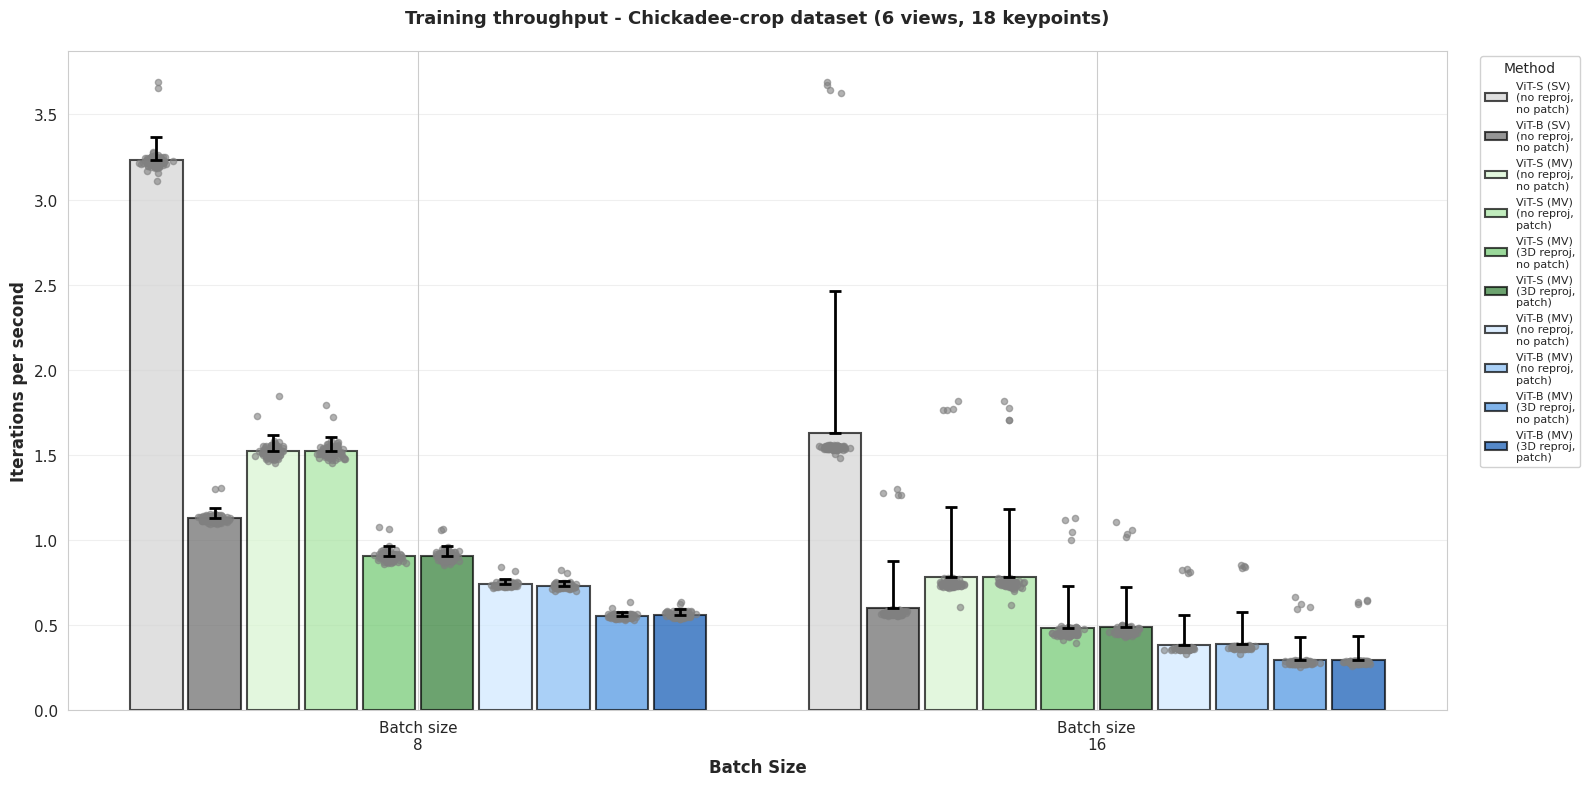


4. Creating inference throughput plot...


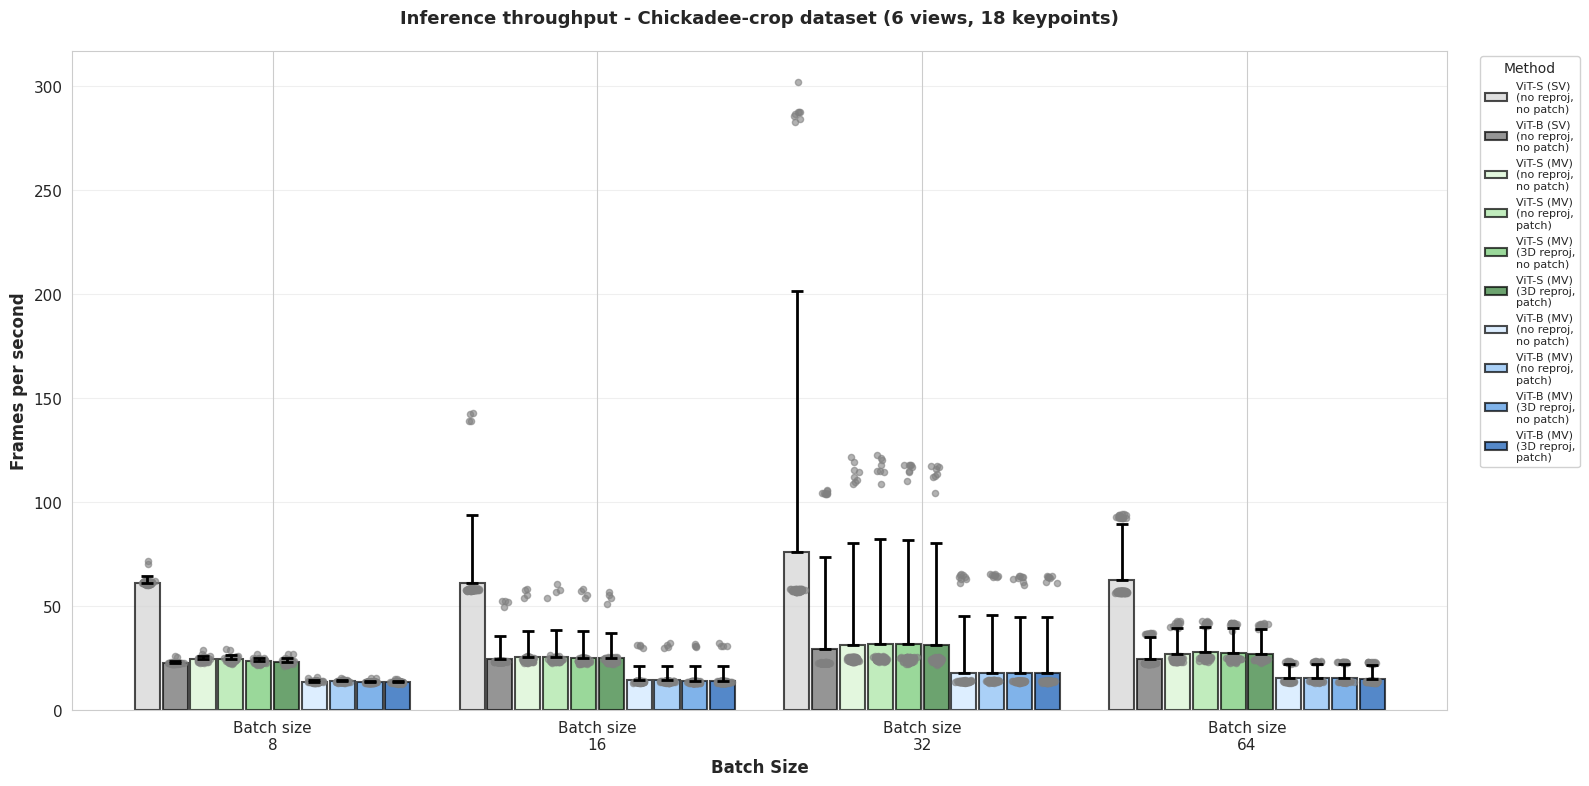


✅ All plots created and saved!

Saved files:
  - training_time_comparison.png (batch sizes: 8, 16, 32)
  - inference_time_comparison.png (batch sizes: 8, 16, 32, 64)
  - training_throughput_comparison.png (batch sizes: 8, 16, 32)
  - inference_throughput_comparison.png (batch sizes: 8, 16, 32, 64)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11


# Folder names from benchmark_nature_training_inference.generate_results_dir_name, e.g.:
#   vits_3dreproj_no_patch_train_batch8
#   vits_3dreproj_patch_patch_train_batch8  (reproj + patch masking)
#   vits_no_loss_patch_train_batch8
#   SV_vits_no_loss_no_patch_train_batch8
_FOLDER_NAME_RE = re.compile(
    r"^(?P<arch>SV_vits|SV_vitb|vits|vitb)_"
    r"(?P<loss_token>no_loss|3dreproj|3dreproj_patch)_"
    r"(?P<patch>no_patch|patch)_"
    r"(?P<mode>train|inference)_batch(?P<batch>\d+)$"
)


def load_all_results(base_dir: str = "/teamspace/studios/this_studio/output_training_time_chickadee"):
    """Load all benchmark results with robust parsing."""
    base_path = Path(base_dir)
    all_results = []
    csv_files = list(base_path.glob("*/benchmark_results.csv"))

    print(f"Found {len(csv_files)} result files")

    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            folder_name = csv_file.parent.name

            m = _FOLDER_NAME_RE.match(folder_name)
            if not m:
                print(f"  ⚠️  Could not parse folder name: {folder_name}")
                continue

            arch_prefix = m.group("arch")
            loss_token = m.group("loss_token")
            patch = m.group("patch")
            mode = m.group("mode")
            batch_size = int(m.group("batch"))

            if arch_prefix.startswith("SV_"):
                is_single_view = True
                base_arch = arch_prefix.replace("SV_", "")
                arch = arch_prefix
            else:
                is_single_view = False
                base_arch = arch_prefix
                arch = arch_prefix

            # Nature benchmarks: 3dreproj* = supervised_reprojection_heatmap_mse (not pairwise 3dloss)
            if loss_token == "no_loss":
                loss = "no_loss"
            elif loss_token in ("3dreproj", "3dreproj_patch"):
                loss = "3d_reproj"
            else:
                loss = loss_token

            df["scenario_arch"] = arch
            df["scenario_base_arch"] = base_arch
            df["scenario_is_single_view"] = is_single_view
            df["scenario_loss"] = loss
            df["scenario_patch"] = patch
            df["scenario_mode"] = mode
            df["scenario_batch_size"] = batch_size
            df["folder_name"] = folder_name

            all_results.append(df)

        except Exception as e:
            print(f"  ⚠️  Error loading {csv_file.name}: {e}")
            continue

    if not all_results:
        return None

    combined_df = pd.concat(all_results, ignore_index=True)
    print(f"\nLoaded {len(combined_df)} total batch records")
    print(f"Architectures found: {combined_df['scenario_arch'].unique()}")
    return combined_df


def create_method_label(row):
    """Create a readable method label from scenario."""
    # Map architecture names
    arch_map = {
        'vits': 'ViT-S (MV)',  # Multiview
        'vitb': 'ViT-B (MV)',  # Multiview
        'SV_vits': 'ViT-S (SV)',  # Single-view
        'SV_vitb': 'ViT-B (SV)',  # Single-view
    }
    arch = arch_map.get(row['scenario_arch'], row['scenario_arch'])

    # Chickadee-crop benchmarks use reprojection MSE (3d_reproj), not pairwise 3dloss
    loss_str = '3D reproj' if row['scenario_loss'] == '3d_reproj' else 'no reproj'
    patch_str = 'patch' if row['scenario_patch'] == 'patch' else 'no patch'

    return f"{arch}\n({loss_str},\n{patch_str})"


def plot_training_time_comparison(df: pd.DataFrame, mode: str = "train"):
    """Create publication-quality plot similar to reference figure."""
    
    mode_df = df[df['scenario_mode'] == mode].copy()
    
    if len(mode_df) == 0:
        print(f"No data for mode: {mode}")
        return None
    
    # Filter batch sizes based on mode
    allowed_batch_sizes = [8, 16, 32] if mode == "train" else [8, 16, 32, 64]
    mode_df = mode_df[mode_df['scenario_batch_size'].isin(allowed_batch_sizes)]
    
    if len(mode_df) == 0:
        print(f"No data for mode: {mode} with allowed batch sizes")
        return None
    
    # Create method label
    mode_df['method'] = mode_df.apply(create_method_label, axis=1)
    
    method_order = [
        # ViT-S (SV)
        "ViT-S (SV)\n(no reproj,\nno patch)",
        # ViT-B (SV)
        "ViT-B (SV)\n(no reproj,\nno patch)",
        # ViT-S (MV) — dark (slow) → light (fast)
        "ViT-S (MV)\n(no reproj,\nno patch)",
        "ViT-S (MV)\n(no reproj,\npatch)",
        "ViT-S (MV)\n(3D reproj,\nno patch)",
        "ViT-S (MV)\n(3D reproj,\npatch)",
        # ViT-B (MV)
        "ViT-B (MV)\n(no reproj,\nno patch)",
        "ViT-B (MV)\n(no reproj,\npatch)",
        "ViT-B (MV)\n(3D reproj,\nno patch)",
        "ViT-B (MV)\n(3D reproj,\npatch)",
    ]
    order_rank = {label: idx for idx, label in enumerate(method_order)}
    methods = sorted(
        mode_df['method'].unique(),
        key=lambda m: order_rank.get(m, len(order_rank))
    )
    batch_sizes = sorted(mode_df['scenario_batch_size'].unique())
    
    # Get time column
    time_col = 'time_per_batch'  # in seconds
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 8))  # Wider to accommodate more methods
    
    # Color palette for methods
    custom_palette = {
        # ViT-S (MV): light → dark green
        "ViT-S (MV)\n(no reproj,\nno patch)": "#d8f5d0",
        "ViT-S (MV)\n(no reproj,\npatch)":    "#a7e4a1",
        "ViT-S (MV)\n(3D reproj,\nno patch)":    "#6fc86f",
        "ViT-S (MV)\n(3D reproj,\npatch)":       "#2e7d32",
        # ViT-B (MV): light → dark blue
        "ViT-B (MV)\n(no reproj,\nno patch)": "#cfe8ff",
        "ViT-B (MV)\n(no reproj,\npatch)":    "#86bdf5",
        "ViT-B (MV)\n(3D reproj,\nno patch)":    "#4b93e2",
        "ViT-B (MV)\n(3D reproj,\npatch)":       "#0b56b3",
    }
    
    default_colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
    fallback_cycle = iter(default_colors)
    
    method_colors = {}
    for method in methods:
        if method.startswith("ViT-S (SV)"):
            method_colors[method] = "lightgray"
        elif method.startswith("ViT-B (SV)"):
            method_colors[method] = "dimgray"
        elif method in custom_palette:
            method_colors[method] = custom_palette[method]
        else:
            method_colors[method] = next(fallback_cycle)
    
    # Calculate positions for grouped bars
    n_methods = len(methods)
    n_batches = len(batch_sizes)
    width = 0.12  # Slightly narrower to fit more methods
    group_width = n_methods * width + 0.2  # Total width of one batch size group
    
    x_positions = []
    bar_positions = {}
    
    for batch_idx, batch_size in enumerate(batch_sizes):
        group_center = batch_idx * group_width + group_width / 2
        x_positions.append(group_center)
        
        for method_idx, method in enumerate(methods):
            offset = (method_idx - (n_methods - 1) / 2) * width
            bar_positions[(batch_size, method)] = group_center + offset
    
    # Plot bars and scatter points
    for method in methods:
        method_data = mode_df[mode_df['method'] == method]
        color = method_colors[method]
        
        for batch_size in batch_sizes:
            batch_data = method_data[method_data['scenario_batch_size'] == batch_size]
            
            if len(batch_data) == 0:
                continue
            
            # Calculate mean and std
            mean_time = batch_data[time_col].mean()
            std_time = batch_data[time_col].std()
            
            # Bar position
            x_pos = bar_positions[(batch_size, method)]
            
            # Plot bar
            ax.bar(
                x_pos,
                mean_time,
                width=width * 0.9,
                color=color,
                alpha=0.7,
                edgecolor='black',
                linewidth=1.5,
                label=method if batch_size == batch_sizes[0] else ""  # Label only once
            )
            
            # Plot individual scatter points
            scatter_x = np.random.normal(x_pos, width * 0.1, size=len(batch_data))
            ax.scatter(
                scatter_x,
                batch_data[time_col].values,
                color='gray',
                s=20,
                alpha=0.6,
                zorder=5
            )
            
            # Plot error bar (std)
            ax.errorbar(
                x_pos,
                mean_time + std_time,
                yerr=std_time,
                color='black',
                capsize=4,
                capthick=2,
                elinewidth=2,
                fmt='none',
                zorder=6
            )
    
    # Set log scale for y-axis
    ax.set_yscale('log')
    ax.set_ylabel('Time per batch (s) (log scale)', fontsize=12, fontweight='bold')
    
    # Set x-axis
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f'Batch size\n{bs}' for bs in batch_sizes], fontsize=11)
    ax.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
    
    # Title
    mode_title = "Training" if mode == "train" else "Inference"
    ax.set_title(
        f'{mode_title} time per batch (load data + forward/backward) - Chickadee-crop dataset (6 views, 18 keypoints)',
        fontsize=13,
        fontweight='bold',
        pad=20
    )
    
    # Legend
    ax.legend(
        title='Method',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=8,  # Slightly smaller to fit more methods
        title_fontsize=10,
        framealpha=0.9
    )
    
    # Grid
    ax.grid(True, alpha=0.3, axis='y', which='both')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig


def plot_throughput_comparison(df: pd.DataFrame, mode: str = "train"):
    """Plot throughput (iterations/sec or frames/sec) instead of time."""
    
    mode_df = df[df['scenario_mode'] == mode].copy()
    
    if len(mode_df) == 0:
        print(f"No data for mode: {mode}")
        return None
    
    # Filter batch sizes based on mode
    allowed_batch_sizes = [8, 16, 32] if mode == "train" else [8, 16, 32, 64]
    mode_df = mode_df[mode_df['scenario_batch_size'].isin(allowed_batch_sizes)]
    
    if len(mode_df) == 0:
        print(f"No data for mode: {mode} with allowed batch sizes")
        return None
    
    # Create method label
    mode_df['method'] = mode_df.apply(create_method_label, axis=1)
    
    method_order = [
        # ViT-S (SV)
        "ViT-S (SV)\n(no reproj,\nno patch)",
        # ViT-B (SV)
        "ViT-B (SV)\n(no reproj,\nno patch)",
        # ViT-S (MV) — light (fast) → dark (slow)
        "ViT-S (MV)\n(no reproj,\nno patch)",
        "ViT-S (MV)\n(no reproj,\npatch)",
        "ViT-S (MV)\n(3D reproj,\nno patch)",
        "ViT-S (MV)\n(3D reproj,\npatch)",
        
        # ViT-B (MV)
        "ViT-B (MV)\n(no reproj,\nno patch)",
        "ViT-B (MV)\n(no reproj,\npatch)",
        "ViT-B (MV)\n(3D reproj,\nno patch)",
        "ViT-B (MV)\n(3D reproj,\npatch)",
    ]
    order_rank = {label: idx for idx, label in enumerate(method_order)}
    methods = sorted(
        mode_df['method'].unique(),
        key=lambda m: order_rank.get(m, len(order_rank))
    )
    batch_sizes = sorted(mode_df['scenario_batch_size'].unique())
    
    # Get throughput column
    if mode == "train":
        throughput_col = 'iterations_per_second'
        ylabel = 'Iterations per second'
    else:
        throughput_col = 'frames_per_second'
        ylabel = 'Frames per second'
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 8))  # Wider to accommodate more methods
    
    # Color palette
    custom_palette = {
        # ViT-S (MV): light → dark green
        "ViT-S (MV)\n(no reproj,\nno patch)": "#d8f5d0",
        "ViT-S (MV)\n(no reproj,\npatch)":    "#a7e4a1",
        "ViT-S (MV)\n(3D reproj,\nno patch)":    "#6fc86f",
        "ViT-S (MV)\n(3D reproj,\npatch)":       "#2e7d32",
        # ViT-B (MV): light → dark blue
        "ViT-B (MV)\n(no reproj,\nno patch)": "#cfe8ff",
        "ViT-B (MV)\n(no reproj,\npatch)":    "#86bdf5",
        "ViT-B (MV)\n(3D reproj,\nno patch)":    "#4b93e2",
        "ViT-B (MV)\n(3D reproj,\npatch)":       "#0b56b3",
    }
    
    default_colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
    fallback_cycle = iter(default_colors)
    
    method_colors = {}
    for method in methods:
        if method.startswith("ViT-S (SV)"):
            method_colors[method] = "lightgray"
        elif method.startswith("ViT-B (SV)"):
            method_colors[method] = "dimgray"
        elif method in custom_palette:
            method_colors[method] = custom_palette[method]
        else:
            method_colors[method] = next(fallback_cycle)
    
    
    
    # Calculate positions
    n_methods = len(methods)
    width = 0.12  # Slightly narrower
    group_width = n_methods * width + 0.2
    
    x_positions = []
    bar_positions = {}
    
    for batch_idx, batch_size in enumerate(batch_sizes):
        group_center = batch_idx * group_width + group_width / 2
        x_positions.append(group_center)
        
        for method_idx, method in enumerate(methods):
            offset = (method_idx - (n_methods - 1) / 2) * width
            bar_positions[(batch_size, method)] = group_center + offset
    
    # Plot bars and scatter points
    for method in methods:
        method_data = mode_df[mode_df['method'] == method]
        color = method_colors[method]
        
        for batch_size in batch_sizes:
            batch_data = method_data[method_data['scenario_batch_size'] == batch_size]
            
            if len(batch_data) == 0:
                continue
            
            # Calculate mean and std
            mean_throughput = batch_data[throughput_col].mean()
            std_throughput = batch_data[throughput_col].std()
            
            x_pos = bar_positions[(batch_size, method)]
            
            # Plot bar
            ax.bar(
                x_pos,
                mean_throughput,
                width=width * 0.9,
                color=color,
                alpha=0.7,
                edgecolor='black',
                linewidth=1.5,
                label=method if batch_size == batch_sizes[0] else ""
            )
            
            # Plot individual scatter points
            scatter_x = np.random.normal(x_pos, width * 0.1, size=len(batch_data))
            ax.scatter(
                scatter_x,
                batch_data[throughput_col].values,
                color='gray',
                s=20,
                alpha=0.6,
                zorder=5
            )
            
            # Plot error bar
            ax.errorbar(
                x_pos,
                mean_throughput + std_throughput,
                yerr=std_throughput,
                color='black',
                capsize=4,
                capthick=2,
                elinewidth=2,
                fmt='none',
                zorder=6
            )
    
    # Y-axis (linear scale for throughput)
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    
    # X-axis
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f'Batch size\n{bs}' for bs in batch_sizes], fontsize=11)
    ax.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
    
    # Title
    mode_title = "Training" if mode == "train" else "Inference"
    ax.set_title(
        f'{mode_title} throughput - Chickadee-crop dataset (6 views, 18 keypoints)',
        fontsize=13,
        fontweight='bold',
        pad=20
    )
    
    # Legend
    ax.legend(
        title='Method',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=8,  # Slightly smaller
        title_fontsize=10,
        framealpha=0.9
    )
    
    # Grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig


# ============================================================================
# MAIN EXECUTION - Run this cell
# ============================================================================

# Load all results
print("Loading all benchmark results...")
df = load_all_results()

if df is not None:
    print(f"\nCreating publication-quality plots...")
    print(f"Including models: {sorted(df['scenario_arch'].unique())}")
    
    # 1. Training time comparison (log scale) - batch sizes 8, 16, 32
    print("\n1. Creating training time comparison plot...")
    fig1 = plot_training_time_comparison(df, mode="train")
    if fig1:
        fig1.savefig(
            "/teamspace/studios/this_studio/output_training_time_chickadee/training_time_comparison_chickadee.pdf",
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
    
    # 2. Inference time comparison (log scale) - batch sizes 8, 16, 32, 64
    print("\n2. Creating inference time comparison plot...")
    fig2 = plot_training_time_comparison(df, mode="inference")
    if fig2:
        fig2.savefig(
            "/teamspace/studios/this_studio/output_training_time_chickadee/inference_time_comparison_chickadee.pdf",
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
    
    # 3. Training throughput (linear scale) - batch sizes 8, 16, 32
    print("\n3. Creating training throughput plot...")
    fig3 = plot_throughput_comparison(df, mode="train")
    if fig3:
        fig3.savefig(
            "/teamspace/studios/this_studio/output_training_time_chickadee/training_throughput_comparison_chickadee.pdf",
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
    
    # 4. Inference throughput (linear scale) - batch sizes 8, 16, 32, 64
    print("\n4. Creating inference throughput plot...")
    fig4 = plot_throughput_comparison(df, mode="inference")
    if fig4:
        fig4.savefig(
            "/teamspace/studios/this_studio/output_training_time_chickadee/inference_throughput_comparison_chickadee.pdf",
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
    
    print("\n✅ All plots created and saved!")
    print("\nSaved files:")
    print("  - training_time_comparison.png (batch sizes: 8, 16, 32)")
    print("  - inference_time_comparison.png (batch sizes: 8, 16, 32, 64)")
    print("  - training_throughput_comparison.png (batch sizes: 8, 16, 32)")
    print("  - inference_throughput_comparison.png (batch sizes: 8, 16, 32, 64)")
else:
    print("❌ No data loaded. Check that benchmark results exist.")
